In [3]:
import os, sys
from pprint import pprint
import matplotlib.pyplot as plt
import matplotlib.patches as patches






sys.path.append(os.path.dirname(os.getcwd()))
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
from env_constants import PYGARMENT_ROOT, DATASET_ROOT

module_path = os.path.abspath(os.path.dirname(os.getcwd()))
if module_path not in sys.path:
    sys.path.append(module_path)




sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg


In [5]:
import os 
import sys


import pickle
import numpy as np
import svgpathtools as svgpath
from PIL import Image
from copy import deepcopy
from torch.utils.data import Dataset
import random


from dataclasses import dataclass, field
from typing import List, Dict, Tuple
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


@dataclass
class Stitch :
    panel_0 : str
    edge_0 : int
    panel_1 : str
    edge_1 : int
    stitch_direction : bool
    

class StitchDict:
    def __init__(self, raw_stitch_dict: Dict[int, List[Dict]]):
        """
        Initialize the StitchManager from a raw stitch dictionary.        
        raw_stitch_dict: keys are stitch ids and values are lists of two dictionaries
                         with 'panel' and 'edge' keys.
        """
        self._stitches: Dict[int, Stitch] = {}
        for stitch_id, stitch_pair in raw_stitch_dict.items():
            # Each stitch_pair contains two entries representing the two sides of the stitch.
            side0 = stitch_pair[0]
            side1 = stitch_pair[1]
            # Optionally, you could compute stitch_direction from panel names or edges.
            stitch_direction = False  # You can update this logic as needed.
            self._stitches[stitch_id] = Stitch(
                panel_0=side0['panel'],
                edge_0=side0['edge'],
                panel_1=side1['panel'],
                edge_1=side1['edge'],
                stitch_direction=stitch_direction
            )
    
    def reindex(
        self,
        mapping: Dict[int, int],
    ) -> None:
        """
        Re-index the internal dictionary using a provided mapping.
        For example, mapping could be ann_to_img_seam_idx_map or img_to_ann_seam_idx_map.
        """
        new_stitches = {}
        for old_key, stitch in self._stitches.items():
            new_key = mapping.get(old_key, old_key)
            new_stitches[new_key] = stitch
        self._stitches = new_stitches
    
    def __getitem__(self, key: int) -> Stitch:
        return self._stitches[key]
    
    def __setitem__(self, key: int, value: Stitch) -> None:
        self._stitches[key] = value
    
    def items(self):
        return self._stitches.items()
    
    def __repr__(self):
        return repr(self._stitches)


class SVGPanel:
    def __init__(self, svg_path: List[svgpath.Path]):
        self.svg_path = svg_path

    def translate(self, dx: float, dy: float) -> None:
        """
        Translate the panel by dx along x-axis and dy along y-axis.
        """
        # In the complex plane, translation by (dx, dy) means adding (dx + dy*j)
        delta = dx + dy * 1j
        self.svg_path = svgpath.Path(*[path.translated(delta) for path in self.svg_path])


    def scale(self, factor: float, pivot: np.ndarray = np.array([0, 0])) -> None:
        """
        Scale the panel by the given factor relative to the pivot.
        By default, the pivot is 0 (the origin), but you can specify a different pivot point.
        """
        pivot_complex = pivot[0] + pivot[1] * 1j
        self.svg_path = svgpath.Path(*[
            (path.translated(-pivot_complex)).scaled(factor).translated(pivot_complex) for path in self.svg_path
        ])
        
    def rotate_clockwise(self, angle_degrees: float, pivot: np.ndarray = np.array([0, 0])) -> None:
        """
        Rotate the entire path by a given angle in degrees around a pivot point.
        
        Args:
            angle_degrees: The angle to rotate the path, in degrees.
            pivot: The point around which to rotate the path. Default is the origin (0+0j).
        """
        pivot_complex = pivot[0] + pivot[1] * 1j
        self.svg_path = svgpath.Path(*[
            path.rotated(angle_degrees, pivot_complex) for path in self.svg_path
        ])
        
    def mirror_horizontal(self) -> None:
        """
        Mirror the panel horizontally (flip the x-axis).
        """
        # self.svg_path = [svgpath.Path(*[self._mirror_horizontal_segment(seg) for seg in path]) for path in self.svg_path]
        self.svg_path = svgpath.Path(*[self._mirror_horizontal_segment(seg) for seg in self.svg_path])        

    def mirror_vertical(self) -> None:
        """
        Mirror the panel vertically (flip the y-axis).
        """
        # self.svg_path = [svgpath.Path(*[self._mirror_vertical_segment(seg) for seg in path]) for path in self.svg_path]
        self.svg_path = svgpath.Path(*[self._mirror_vertical_segment(seg) for seg in self.svg_path])

    def _mirror_horizontal_segment(self, segment):
        if isinstance(segment, svgpath.Arc):
            # Mirror the start and end points horizontally
            start = complex(-segment.start.real, segment.start.imag)
            end = complex(-segment.end.real, segment.end.imag)
            # Reverse the sweep flag
            sweep = not segment.sweep
            return svgpath.Arc(start=start, radius=segment.radius, rotation=segment.rotation,
                       large_arc=segment.large_arc, sweep=sweep, end=end)
        else:
            return segment.scaled(-1, 1)

    def _mirror_vertical_segment(self, segment):
        if isinstance(segment, svgpath.Arc):
            # Mirror the start and end points vertically
            start = complex(segment.start.real, -segment.start.imag)
            end = complex(segment.end.real, -segment.end.imag)
            # Reverse the sweep flag
            sweep = not segment.sweep
            return svgpath.Arc(start=start, radius=segment.radius, rotation=segment.rotation,
                       large_arc=segment.large_arc, sweep=sweep, end=end)
        else:
            return segment.scaled(1, -1)

    def draw(
        self,
        ax          : plt.Axes = None,
        panel_name  : str = None,
        N_SAMPLE_PER_EDGE : int = 80,
        edge_color_list : List[Tuple[float, float, float]] = None
    ) -> None:
        
        if ax is None :
            ax = plt.gca()
        if panel_name is not None :
            ax.set_title(panel_name)
        for edge_idx, edge in enumerate(self.svg_path) :
            for dx, dy in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
                ax.annotate(
                    f"{edge_idx}",
                    [edge.start.real + dx, edge.start.imag + dy],
                    color = "white", fontweight = "bold",
                    fontsize = 9
                )
            ax.annotate(
                f"{edge_idx}",
                [edge.start.real, edge.start.imag],
                color = "black", # fontweight = "bold",
                fontsize = 9
            )
            ax.add_patch(
                FancyArrowPatch(
                    [edge.start.real, edge.start.imag],
                    [edge.end.real, edge.end.imag],
                    arrowstyle='-|>',
                    mutation_scale=15,
                    color = "black",
                    linewidth = 0.5
                )
            )
            
            ax.scatter(
                list(map(lambda t : edge.point(t).real, np.linspace(0, 1, N_SAMPLE_PER_EDGE))),
                list(map(lambda t : edge.point(t).imag, np.linspace(0, 1, N_SAMPLE_PER_EDGE))),
                s = 0.5
            )
        ax.invert_yaxis()
        ax.axis("equal")
        
    def is_clockwise(self) -> bool:
        """
        Determine if the path is clockwise.
        """
        total = 0
        for segment in self.svg_path:
            start = segment.start
            end = segment.end
            total += (end.real - start.real) * (end.imag + start.imag)
        return total <= 0

    def reverse_path(self) -> None:
        """
        Reverse the order of the path segments and their directions.
        """
        
        reversed_segments = []
        for segment in reversed(self.svg_path):
            reversed_segment = segment.reversed()
            reversed_segments.append(reversed_segment)
        self.svg_path = svgpath.Path(*reversed_segments)
        
    def set_start(self, idx: int) -> None :
        """
        Set the start point of the path to the point at index idx.
        """
        self.svg_path = svgpath.Path(*(self.svg_path[idx:] + self.svg_path[:idx]))
        

    def min_distance_to_point(self, point: complex) -> float:
        """
        Calculate the minimum distance from any point on the panel to a given point.
        
        Args:
            point: A complex number representing the point in the complex plane.
            
        Returns:
            float: The minimum distance from any point on the panel to the given point.
        """
        min_distance = float('inf')
        for path in self.svg_path:
            for segment in path:
                distance = segment.distance(point)
                if distance < min_distance:
                    min_distance = distance
        return min_distance
    
    def bbox(self) :
        """
        (xmin, ymin, xmax, ymax)
        """
        xmin, xmax, ymin, ymax = svgpath.Path(*self.svg_path).bbox()
        return xmin, ymin, xmax, ymax
    
    def get_center(self) :
        xmin, ymin, xmax, ymax = self.bbox()
        return np.array([(xmin + xmax) / 2, (ymin + ymax) / 2])
    
    def __repr__(self):
        return f"Panel(svg_path={self.svg_path})"



class SingleViewLabel :
    """
    class for label of single image
    """    
    def __init__(self,
        img_arr : np.ndarray,
        img_foreground_mask : np.ndarray,
        img_background_mask : np.ndarray,
        img_seam_mask : np.ndarray,
    ) :
        pass



def get_poc_dataset_view_name_list() :
    return ["front", "back", "left", "right"]


def get_bbox_from_mask(img_mask) :
    """
    (x1, y1, x2, y2)
    """
    fg_ycoord, fg_xcoord = np.where(img_mask > 0)
    fg_ycoord_min = np.min(fg_ycoord)
    fg_ycoord_max = np.max(fg_ycoord)
    fg_xcoord_min = np.min(fg_xcoord)
    fg_xcoord_max = np.max(fg_xcoord)
    return (fg_xcoord_min, fg_ycoord_min, fg_xcoord_max, fg_ycoord_max)


def read_poc_datapoint(
    garment_path: str,
    return_data_list = [
        "rendered_image_dict",
        "panel_svg_path_dict",
        "stitch_dict",
        "panel_vertex_mask_dict"
        "vertex_visibility_mask_dict",
        "projected_vertex_pose_dict",
        "fltrd_vis_seam_line_dict",
    ]
) :
    garment_id = os.path.basename(garment_path)

    SPEC_FILE_PATH = os.path.join(garment_path, f"{garment_id}_specification.json")
    pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)

    if "rendered_image_dict" in return_data_list :
        rendered_image_dict = {}
        for side in ["front", "back", "left", "right"] :
            rendered_image_dict[side] = Image.open(os.path.join(garment_path, f"rendered_{side}.png"))
    
    if "panel_svg_path_dict" in return_data_list :
        # Get Garment Blueprint
        panel_svg_path_dict = {
            panel_name : pattern._draw_a_panel(
                panel_name, apply_transform=False, fill=True
            )
            for panel_name in pattern.panel_order()
        }
    if "stitch_dict" in return_data_list :
        stitch_dict = {
            i : v for i, v in enumerate(pattern.pattern['stitches'])
        }
    if "panel_vertex_mask_dict" in return_data_list :
        with open(os.path.join(garment_path, f"panel_vertex_mask_dict.pkl"), "rb") as f :
            panel_vertex_mask_dict = pickle.load(f)            
    if "vertex_visibility_mask_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_vertex_visibility_mask.pkl"), "rb") as f :
            vertex_visibility_mask_dict = pickle.load(f)            
    if "projected_vertex_pose_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_projected_vertex_pose.pkl"), "rb") as f :
            projected_vertex_pose_dict = pickle.load(f)
    if "fltrd_vis_seam_line_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_fltrd_vis_seam_line_dict.pkl"), "rb") as f :
            fltrd_vis_seam_line_dict = pickle.load(f)
    return [values for key, values in locals().items() if key in return_data_list]



def read_poc_views(
    garment_path, 
    view_name_list,
) :
    (
        rendered_image_dict,
        panel_svg_path_dict,
        stitch_dict,
        panel_vertex_mask_dict,
        vertex_visibility_mask_dict,
        projected_vertex_pose_dict,
        fltrd_vis_seam_line_dict,
    ) = read_poc_datapoint(
        os.path.join(DATASET_ROOT, garment_path),
        return_data_list = [
            "rendered_image_dict",
            "panel_svg_path_dict",
            "stitch_dict",
            "panel_vertex_mask_dict",
            "vertex_visibility_mask_dict",
            "projected_vertex_pose_dict",
            "fltrd_vis_seam_line_dict",
        ]
    )
    
    img_and_label_list = []
    for view_name in view_name_list :
        img_and_label_list.append(
            (
                rendered_image_dict[view_name],
                fltrd_vis_seam_line_dict[view_name]
            )
        )
    
    
    
def combine_images_and_labels(
    img_and_label_list,
) :
    """
    image_and_label_list : list of tuple (image, label)
    image : PIL.Image.Image
        -  could be 3, or 4 channel image
    label : Dict
    
    """
    bbox_w_h_list = []
    bbox_x_offset_list = []
    bbox_y_offset_list = []
    cropped_img_arr_list = []
    for img, label in img_and_label_list :
        x1, y1, x2, y2 = get_bbox_from_mask(label.img_foreground_mask)
        bbox_w_h_list.append((x2 - x1, y2 - y1))
        bbox_x_offset_list.append(x1)
        bbox_y_offset_list.append(y1)
        cropped_img_arr_list.append(np.array(img.crop((x1, y1, x2, y2)).convert("RGB")))
    
    
    
    

In [6]:
from pathlib import Path
import pandas as pd

# garment_code_data_df = pd.read_csv(os.path.join(
#     PROJECT_ROOT,
#     "EXPERIMENTS_06_joint_finetuning",
#     "CONFIGs",
#     "gcd_max_token_800_no_digit_in_panel_name_panel_count_14_no_large_arc_no_hood.csv"
# ))

garment_code_data_df = pd.read_csv(os.path.join(
    PYGARMENT_ROOT,
    "garment_code_data_meta_df.csv"
))


garment_code_data_df["garment_path"].tolist()
garment_path = garment_code_data_df["garment_path"].tolist()[0]




99266
garments_5000_32/default_body/rand_MOHI04K7ZN


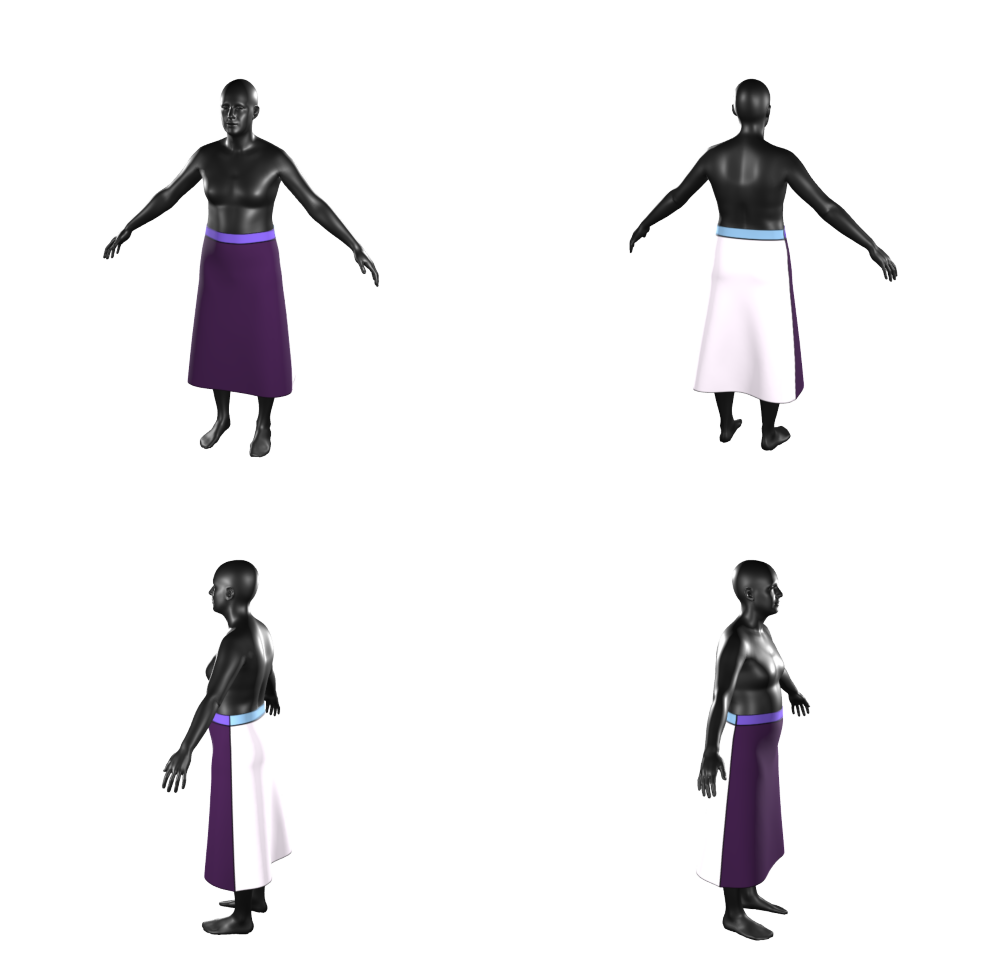

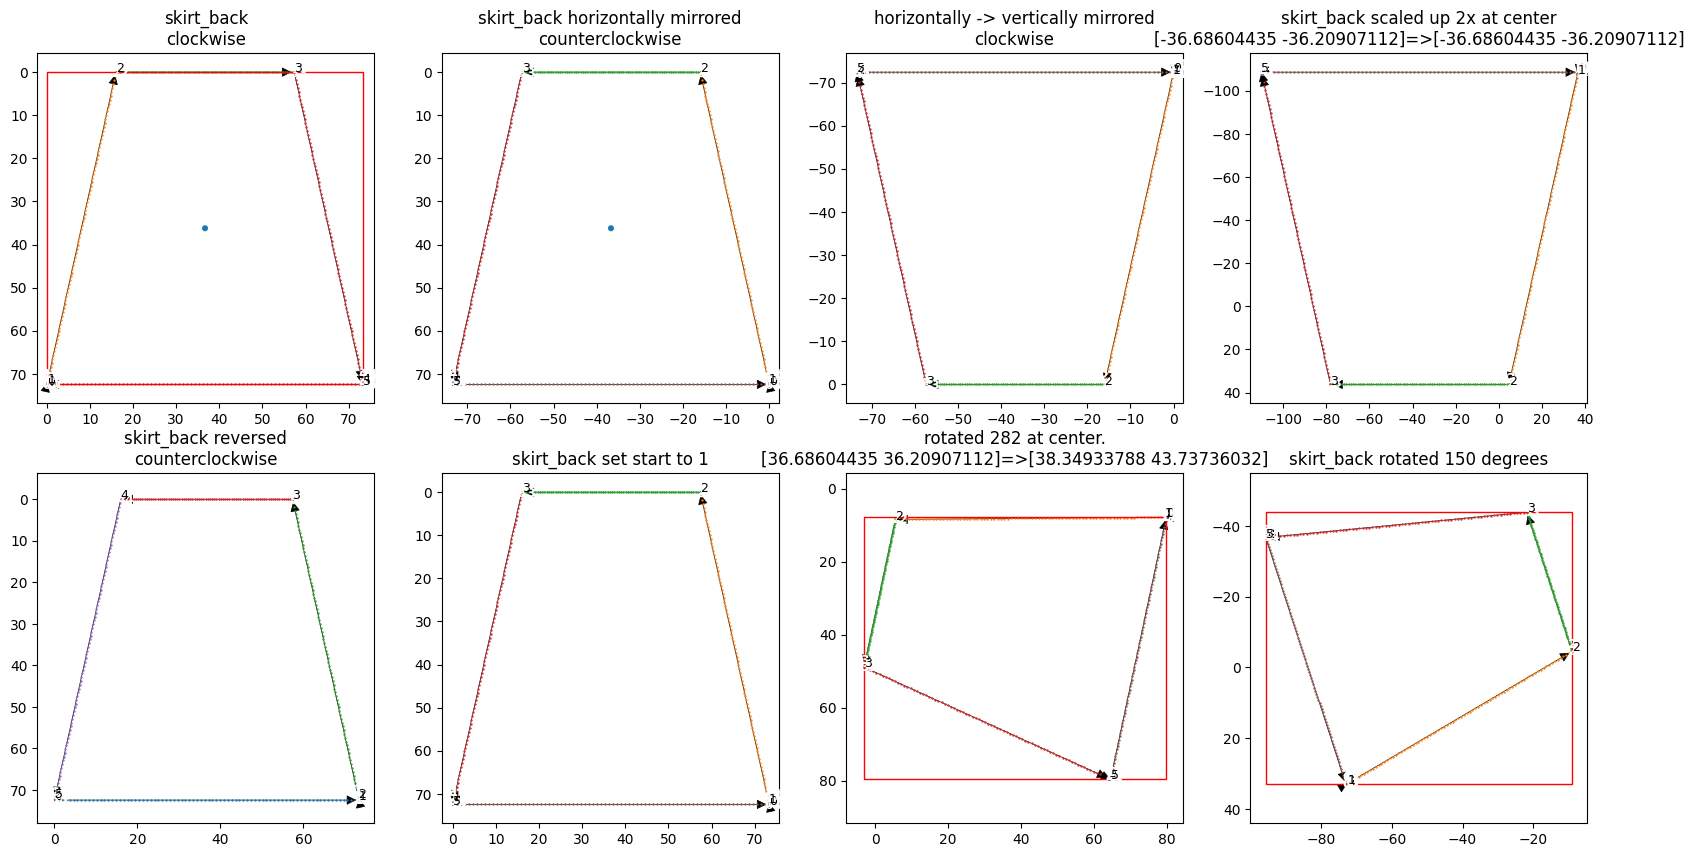

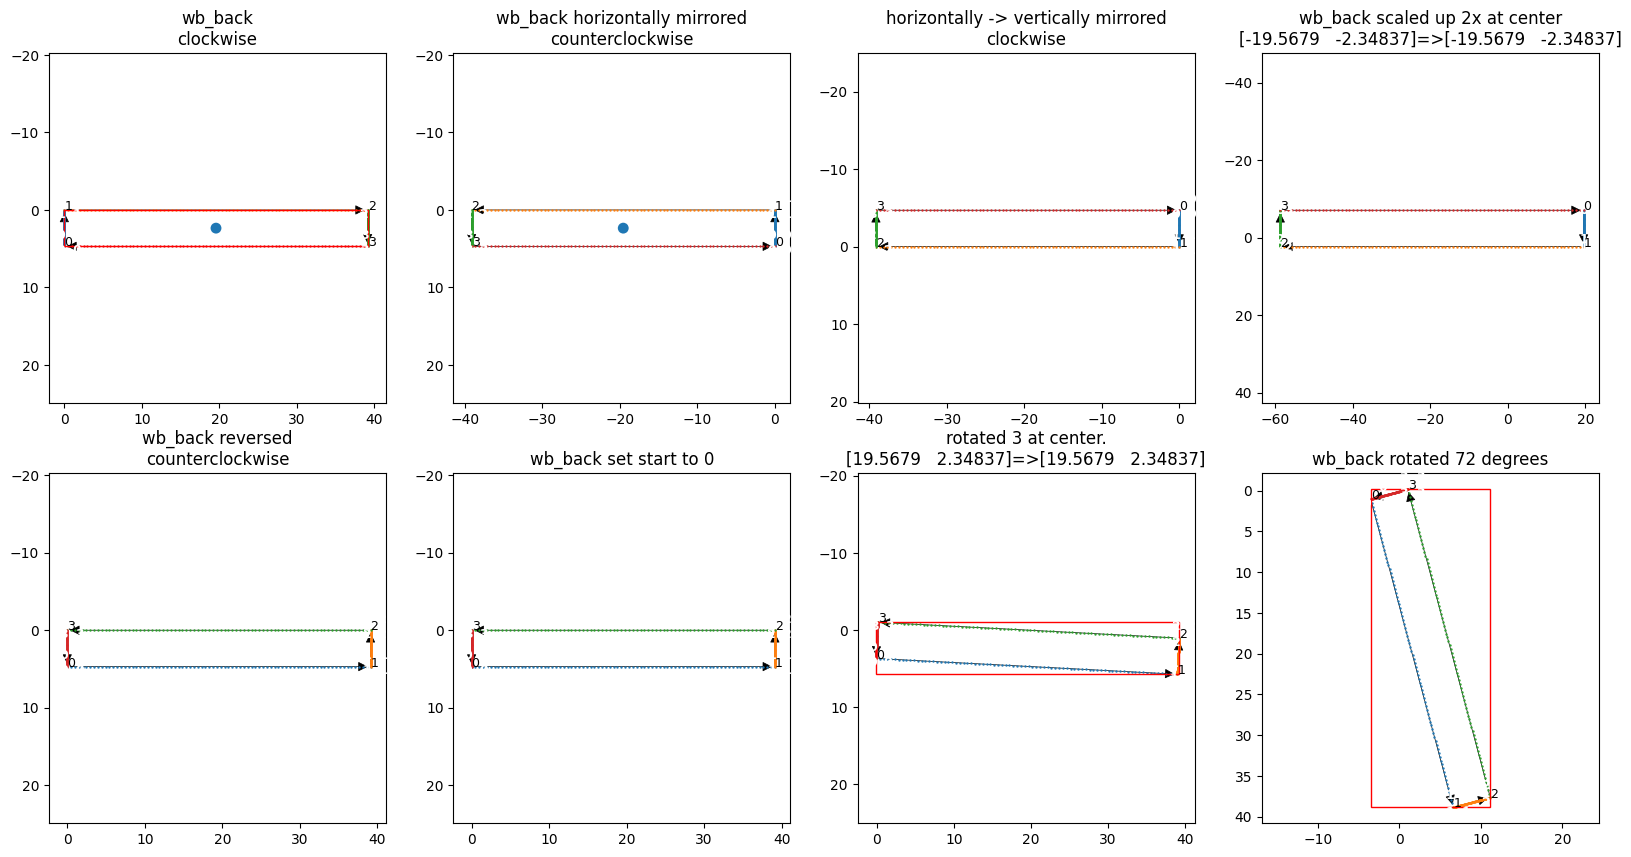

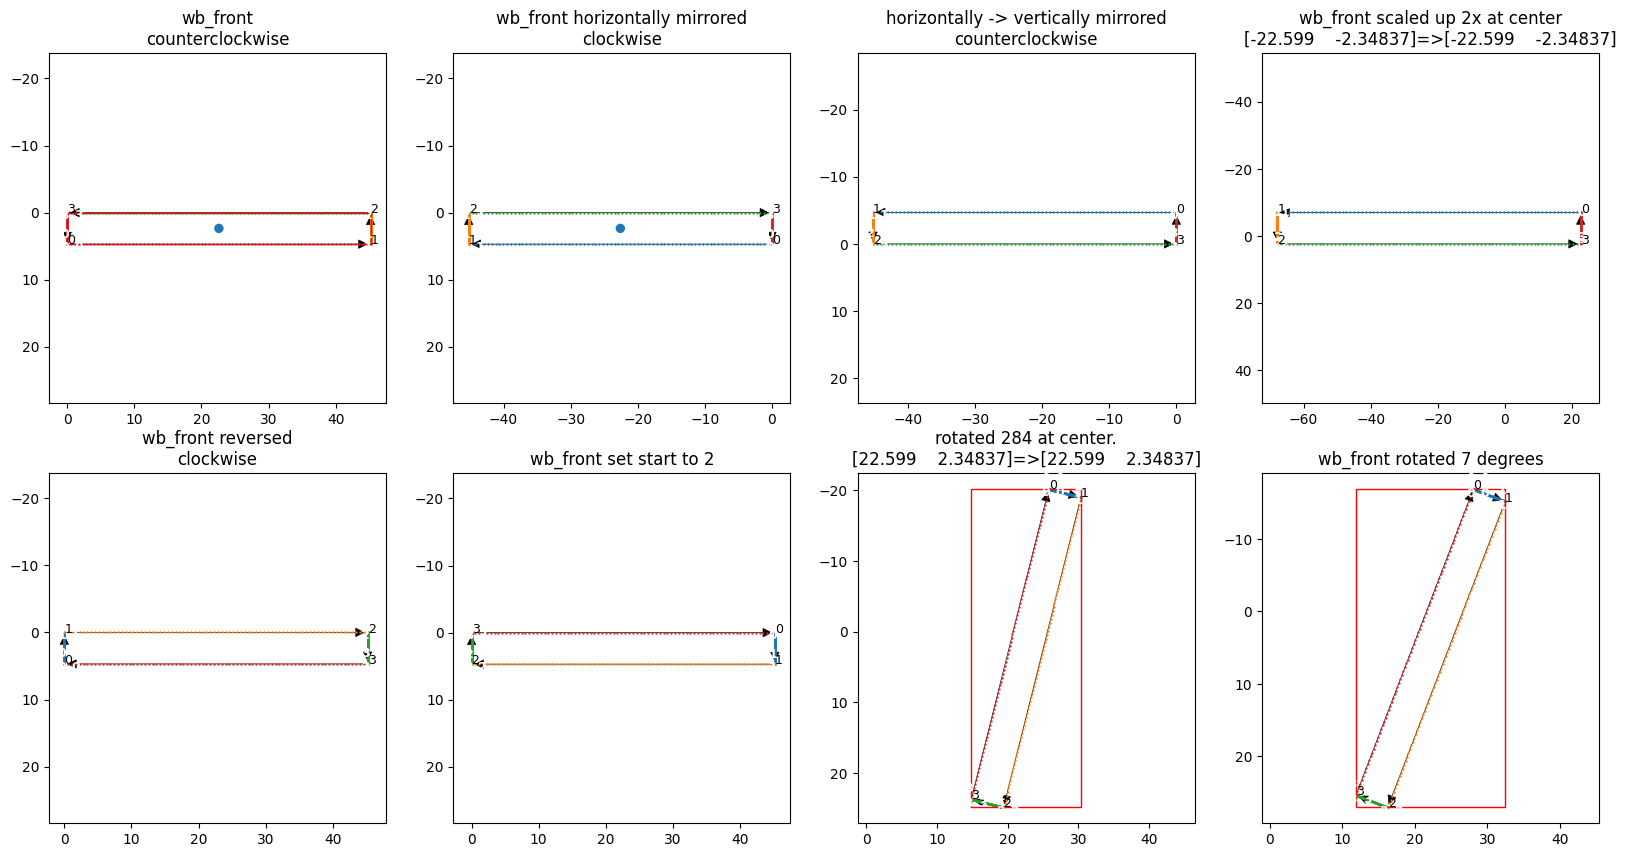

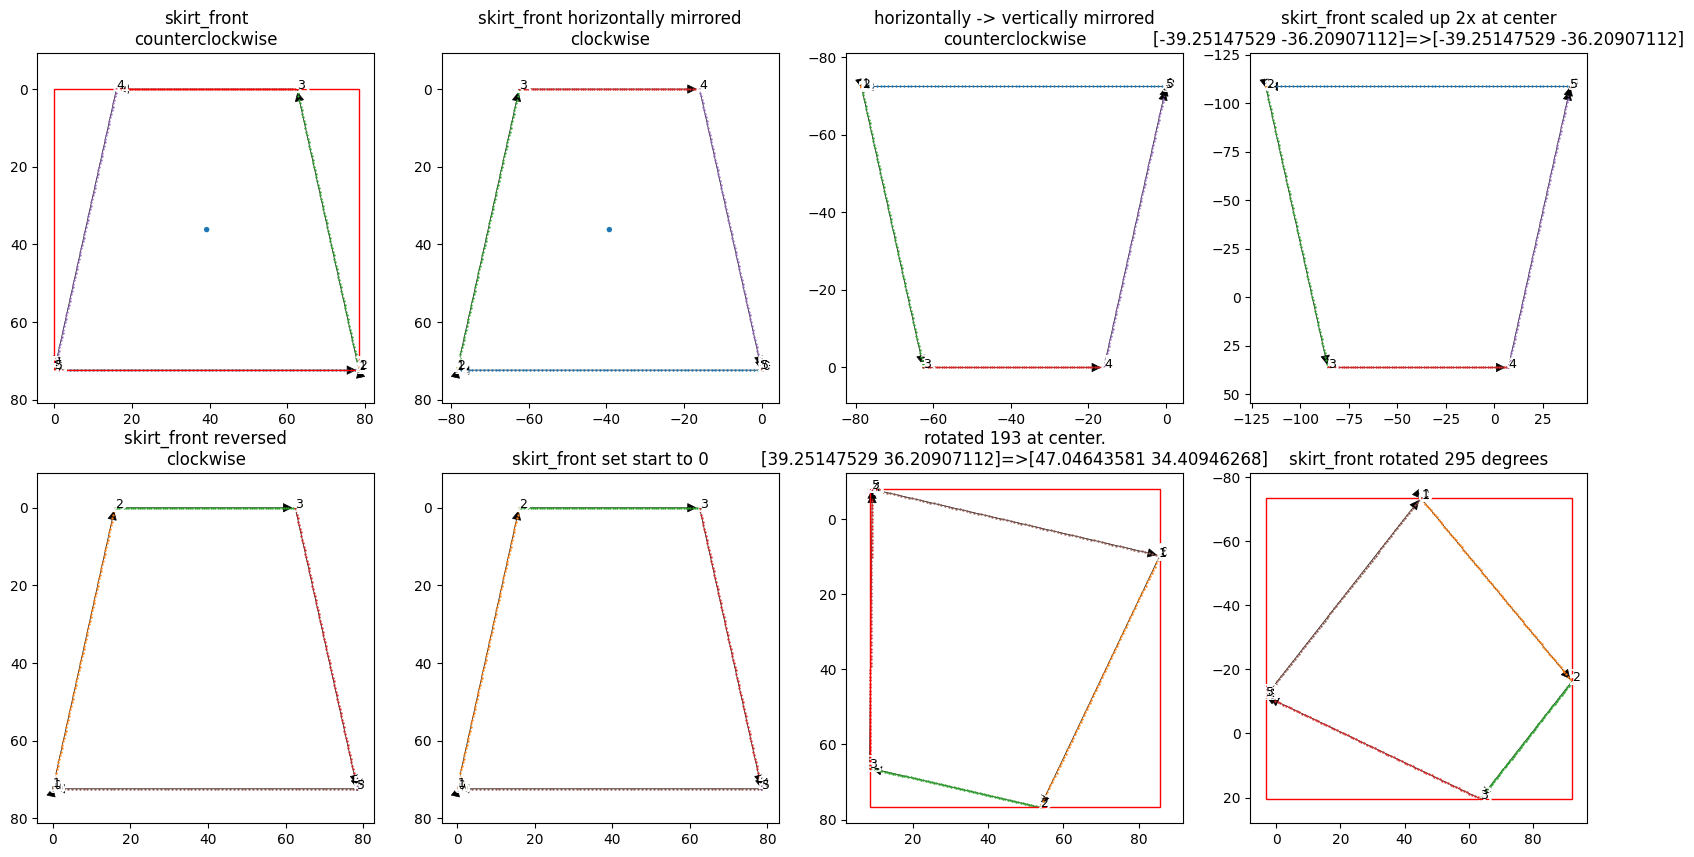

In [7]:
IDX = random.randint(0, len(garment_code_data_df) - 1)
print(IDX)

garment_path = garment_code_data_df["garment_path"].tolist()[IDX]
print(garment_path)


(
    rendered_image_dict,
    panel_svg_path_dict,
    stitch_dict,
    panel_vertex_mask_dict,
    vertex_visibility_mask_dict,
    projected_vertex_pose_dict,
    fltrd_vis_seam_line_dict,
) = read_poc_datapoint(
    os.path.join(DATASET_ROOT, garment_path),
    return_data_list = [
        "rendered_image_dict",
        "panel_svg_path_dict",
        "stitch_dict",
        "panel_vertex_mask_dict",
        "vertex_visibility_mask_dict",
        "projected_vertex_pose_dict",
        "fltrd_vis_seam_line_dict",
    ]
)

NROWS = 2
NCOLS = 2 # /len(rendered_image_dict)

FIGLEN = 5

plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))
for side_idx, (side, image) in enumerate(rendered_image_dict.items()) :
    ax = plt.subplot(NROWS, NCOLS, side_idx + 1)
    plt.imshow(image)
    plt.tight_layout()
    plt.axis("off")
plt.show()



NROWS = 2
NCOLS = 4
FIGLEN = 5
for panel_idx, (panel_name, panel_svg_path) in enumerate(panel_svg_path_dict.items()) :
    fig_idx = 1
    panel = SVGPanel(panel_svg_path_dict[panel_name][0])

    panel_copied = deepcopy(panel)

    plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))


    panel.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = "{}\n{}".format(
            panel_name,
            "clockwise" if panel.is_clockwise() else "counterclockwise"
        ),
    ); fig_idx += 1
    # Draw bbox
    xmin, ymin, xmax, ymax = panel.bbox()
    plt.gca().add_patch(patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        fill=False,
        edgecolor='red',
        linewidth=1
    )) 
    # Draw center
    plt.gca().add_patch(patches.Circle(
        xy = panel.get_center(),
        radius=0.7,
        fill=True,
    ))
    

    panel.mirror_horizontal()
    panel.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = "{}\n{}".format(
            f"{panel_name} horizontally mirrored",
            "clockwise" if panel.is_clockwise() else "counterclockwise"
        ),
    ); fig_idx += 1
    plt.gca().add_patch(patches.Circle(
        xy = panel.get_center(),
        radius=0.7,
        fill=True,
    ))

    panel.mirror_vertical()
    panel.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = "{}\n{}".format(
            f"horizontally -> vertically mirrored",
            "clockwise" if panel.is_clockwise() else "counterclockwise"
        ),
    ); fig_idx += 1

    
    SCALE_FACTOR = 2
    center_before = panel.get_center()
    panel.scale(SCALE_FACTOR, pivot=center_before)
    center_after = panel.get_center()
    panel.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = "{}\n{}".format(
            f"{panel_name} scaled up {SCALE_FACTOR}x at center",
            f"{center_before}=>{center_after}"
        ),
    ); fig_idx += 1

    # ROW 2
    panel_copied.reverse_path()
    panel_copied.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = "{}\n{}".format(
            f"{panel_name} reversed",
            "clockwise" if panel_copied.is_clockwise() else "counterclockwise"
        ),
    ); fig_idx += 1
    
    

    new_start_idx = random.randint(0, len(panel_copied.svg_path) - 1)
    panel_copied.set_start(new_start_idx)
    panel_copied.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = f"{panel_name} set start to {new_start_idx}"
    ); fig_idx += 1
    
    
    angle = random.randint(0, 360)
    center_before = panel_copied.get_center()
    panel_copied.rotate_clockwise(angle, pivot=center_before)
    center_after = panel_copied.get_center()
    panel_copied.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = f"rotated {angle} at center.\n{center_before}=>{center_after}"
    ); fig_idx += 1
    xmin, ymin, xmax, ymax = panel_copied.bbox()
    plt.gca().add_patch(patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        fill=False,
        edgecolor='red',
        linewidth=1
    )) 
    
    angle = random.randint(0, 360)
    panel_copied.rotate_clockwise(angle)
    panel_copied.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = f"{panel_name} rotated {angle} degrees"
    ); fig_idx += 1
    xmin, ymin, xmax, ymax = panel_copied.bbox()
    plt.gca().add_patch(patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        fill=False,
        edgecolor='red',
        linewidth=1
    )) 
    
    
    plt.show()
    
    
